# 176. Second Highest Salary
https://leetcode.com/problems/second-highest-salary/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| IFNULL + Subquery | O(n) | O(1) | Handles NULL case |
| LIMIT + OFFSET | O(n log n) | O(1) | Uses sorting |
| DENSE_RANK Window | O(n log n) | O(n) | Window function |

## Methodology

This is a SQL problem. The key challenge is returning NULL when there is no second highest salary.
We use a subquery with DISTINCT and ORDER BY to find the second highest, wrapped in IFNULL
to handle the edge case where only one distinct salary exists.

## Solutions

### C#

In [ ]:
// SQL Problem - Second Highest Salary
// SQL Solution:
//
// SELECT IFNULL(
//     (SELECT DISTINCT salary
//      FROM Employee
//      ORDER BY salary DESC
//      LIMIT 1 OFFSET 1),
//     NULL
// ) AS SecondHighestSalary;
//
// Alternative using subquery:
//
// SELECT MAX(salary) AS SecondHighestSalary
// FROM Employee
// WHERE salary < (SELECT MAX(salary) FROM Employee);

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Solution
{
    public static int? GetSecondHighestSalary(List<int> salaries)
    {
        var distinct = salaries.Distinct().OrderByDescending(s => s).ToList();
        return distinct.Count >= 2 ? distinct[1] : (int?)null;
    }
}

// Test
var salaries = new List<int> { 100, 200, 300 };
Console.WriteLine(Solution.GetSecondHighestSalary(salaries)); // 200
Console.WriteLine(Solution.GetSecondHighestSalary(new List<int> { 100 })); // null

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
// 
// def second_highest_salary(salaries):
//     distinct = sorted(set(salaries), reverse=True)
//     return distinct[1] if len(distinct) >= 2 else None
//
// # Using pandas (closer to SQL):
// # import pandas as pd
// # def second_highest_salary(df):
// #     result = df['salary'].drop_duplicates().nlargest(2)
// #     return result.iloc[1] if len(result) >= 2 else None

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// func secondHighestSalary(salaries []int) *int {
//     seen := make(map[int]bool)
//     for _, s := range salaries {
//         seen[s] = true
//     }
//     unique := make([]int, 0, len(seen))
//     for s := range seen {
//         unique = append(unique, s)
//     }
//     sort.Sort(sort.Reverse(sort.IntSlice(unique)))
//     if len(unique) >= 2 {
//         return &unique[1]
//     }
//     return nil
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::BTreeSet;
//
// fn second_highest_salary(salaries: &[i32]) -> Option<i32> {
//     let unique: BTreeSet<i32> = salaries.iter().cloned().collect();
//     let sorted: Vec<i32> = unique.into_iter().rev().collect();
//     sorted.get(1).copied()
// }

## Example Scenarios

1. **Common Case:** Employee salaries = `[100, 200, 300]` $\Rightarrow$ `SecondHighestSalary = 200`. Three distinct salaries; `ORDER BY DESC` gives [300, 200, 100]; `LIMIT 1 OFFSET 1` returns 200. $O(n \log n)$ for sorting.

2. **Slightly Complex (Duplicates at Max):** Salaries = `[300, 300, 200, 100]` $\Rightarrow$ `200`. Two employees tied at 300. Without `DISTINCT`, `OFFSET 1` returns 300 again (the second row, same value). `DISTINCT` deduplicates to [300, 200, 100] first. WHY tricky: tests whether the query handles duplicates correctly.

3. **Edge Case (Time):** $10^6$ rows, all with `salary = 50000` $\Rightarrow$ `NULL`. One million employees, one distinct salary. `DISTINCT` collapses to [50000]. `OFFSET 1` yields no row. `IFNULL` wraps to NULL. WHY tricky: DB must scan or index all $10^6$ rows; $O(n \log n)$ sort then DISTINCT reduces to 1.

4. **Edge Case (Space):** Salaries = `[2147483647, 2147483646]` $\Rightarrow$ `2147483646` ($2^{31} - 2$). Boundary values near INT_MAX. The difference is only 1. Some naive approaches subtracting salaries could overflow. WHY tricky: verifies large integer handling without arithmetic overflow.

5. **Almost-Impossible but Plausible:** Single employee with `salary = 100` $\Rightarrow$ `NULL`. Minimum viable table. `DISTINCT` yields [100]; `OFFSET 1` returns empty. Without `IFNULL`, the query returns an empty result set (no rows) instead of a row containing NULL. The problem explicitly requires a row with NULL. WHY tricky: the difference between "no rows" and "one row with NULL" is the entire point of the IFNULL wrapper.

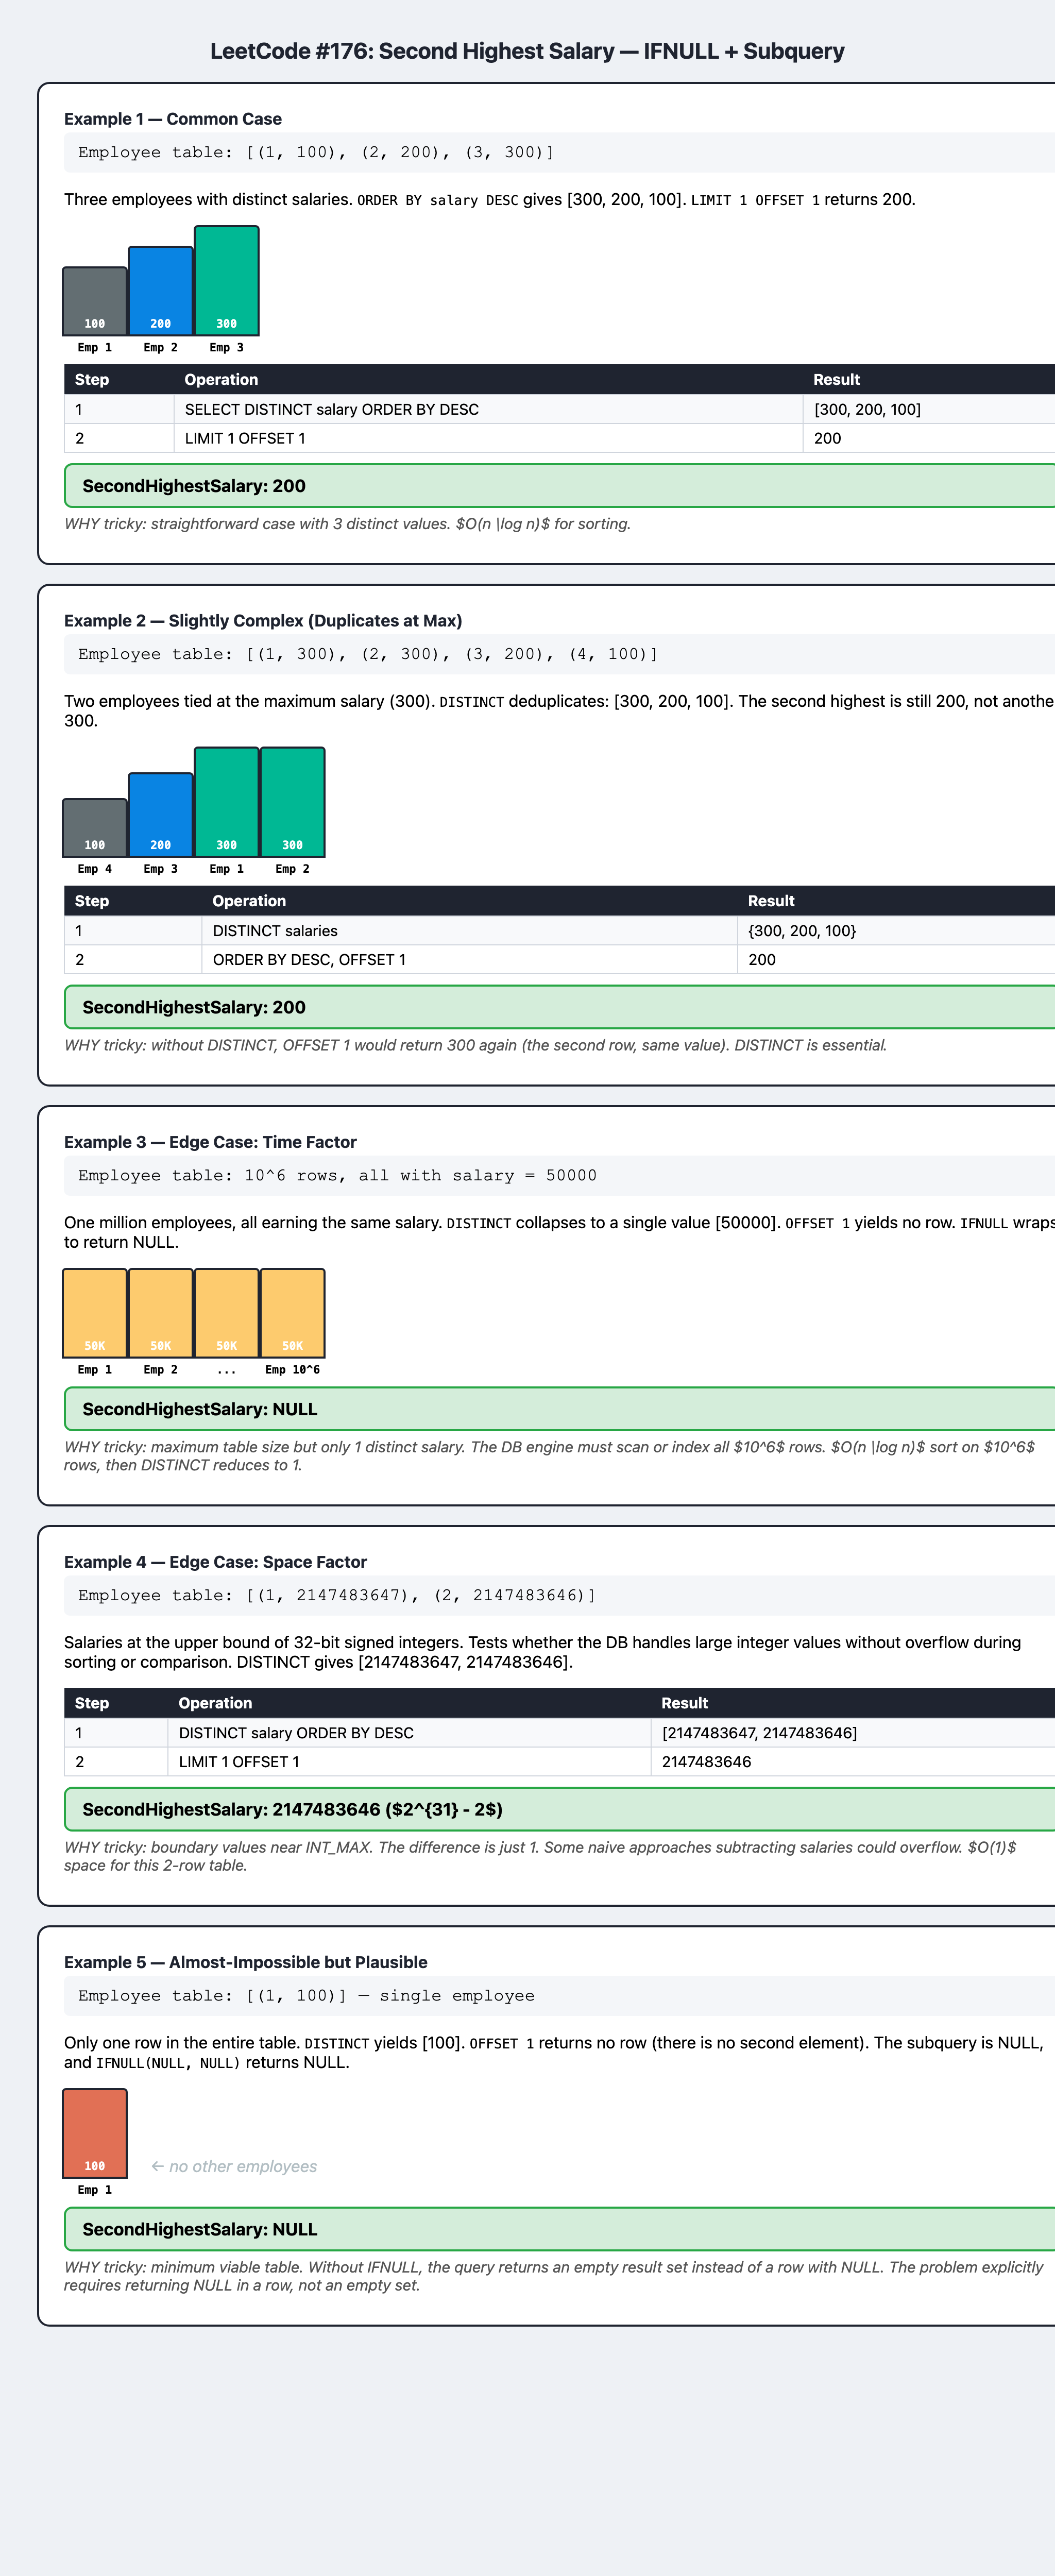